# 02 - EDA & Feature Engineering
### Bank Customer Segmentation using PCA + K-Means

We aggregate the cleaned transaction-level data into **customer-level features**
(RFM-style: Recency, Frequency, Monetary + demographics), since clustering is
performed per-customer, not per-transaction.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

df = pd.read_csv('../data/processed/bank_transactions_clean.csv', parse_dates=['TransactionDate'])
df.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Age
0,T502535,C100726,1966-07-04,Male,Kolkata,213622.83,2024-12-06,230909,6148.90,58.0
1,T500740,C100796,1985-01-13,Female,Chennai,22196.84,2024-06-01,42021,1284.31,39.5
2,T501682,C100135,1976-12-12,Female,Mumbai,52253.95,2024-05-11,183515,323.89,47.5
3,T501409,C100163,1970-08-04,Male,Kolkata,3126.03,2024-07-11,125144,320.57,53.9
4,T505100,C100509,1977-09-18,Male,Bangalore,26256.74,2024-03-20,31024,789.35,46.8


## 1. Univariate exploration

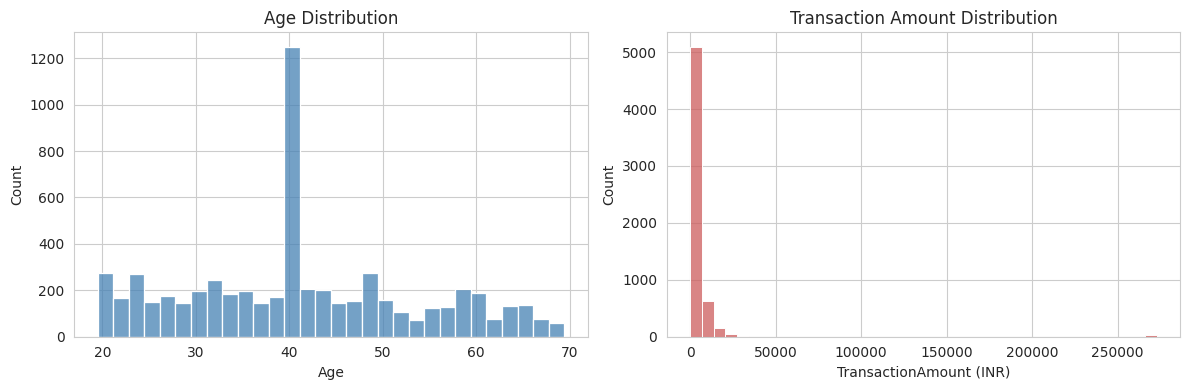

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['Age'], bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Age Distribution')
sns.histplot(df['TransactionAmount (INR)'], bins=40, ax=axes[1], color='indianred')
axes[1].set_title('Transaction Amount Distribution')
plt.tight_layout()
plt.savefig('../reports/figures/univariate_distributions.png', dpi=120)
plt.show()

/tmp/ipykernel_637/3199153393.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='CustGender', order=df['CustGender'].value_counts().index, palette='viridis')


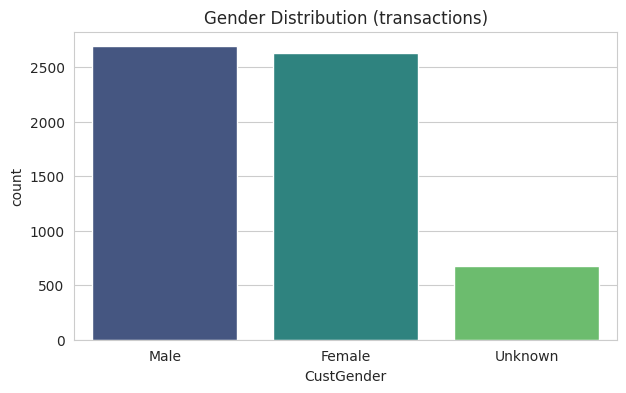

In [3]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='CustGender', order=df['CustGender'].value_counts().index, palette='viridis')
plt.title('Gender Distribution (transactions)')
plt.savefig('../reports/figures/gender_distribution.png', dpi=120)
plt.show()

## 2. Top customer locations

/tmp/ipykernel_637/2647581924.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_loc.values, y=top_loc.index, palette='mako')


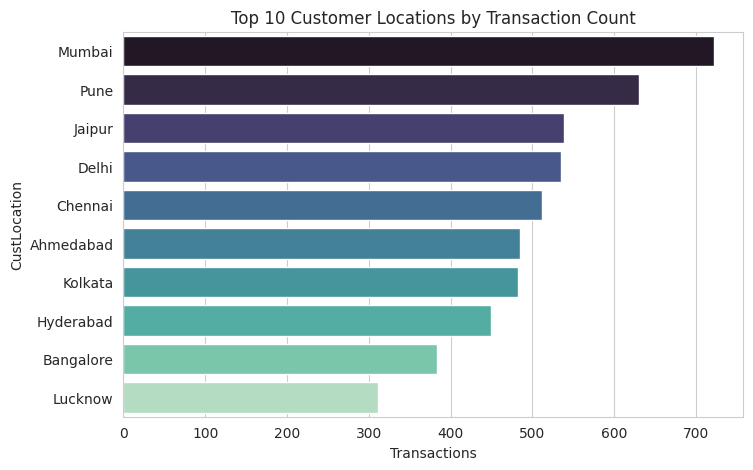

In [4]:
top_loc = df['CustLocation'].value_counts().head(10)
plt.figure(figsize=(8,5))
sns.barplot(x=top_loc.values, y=top_loc.index, palette='mako')
plt.title('Top 10 Customer Locations by Transaction Count')
plt.xlabel('Transactions')
plt.savefig('../reports/figures/top_locations.png', dpi=120)
plt.show()

## 3. Build customer-level RFM + demographic features

- **Recency**: days since the customer's most recent transaction (relative to the dataset's last date)
- **Frequency**: number of transactions made by the customer
- **Monetary**: total (and average) transaction amount per customer
- Plus: Age, Gender, average account balance


In [5]:
snapshot_date = df['TransactionDate'].max() + pd.Timedelta(days=1)

customer_df = df.groupby('CustomerID').agg(
    Recency=('TransactionDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('TransactionID', 'count'),
    Monetary=('TransactionAmount (INR)', 'sum'),
    AvgTransactionAmount=('TransactionAmount (INR)', 'mean'),
    AccountBalance=('CustAccountBalance', 'mean'),
    Age=('Age', 'mean'),
    Gender=('CustGender', lambda x: x.mode().iloc[0]),
).reset_index()

print(customer_df.shape)
customer_df.head()

(778, 8)


,CustomerID,Recency,Frequency,Monetary,AvgTransactionAmount,AccountBalance,Age,Gender
0,C100000,68,5,5227.95,1045.590000,17012.07,40.7,Male
1,C100001,38,22,242430.52,11019.569091,43869.35,48.3,Unknown
2,C100002,113,5,2978.61,595.722000,4740.87,33.7,Female
3,C100003,147,4,6388.16,1597.040000,48217.77,63.3,Unknown
4,C100004,12,3,1983.00,661.000000,13136.92,42.0,Male


## 4. Encode categorical + inspect correlations

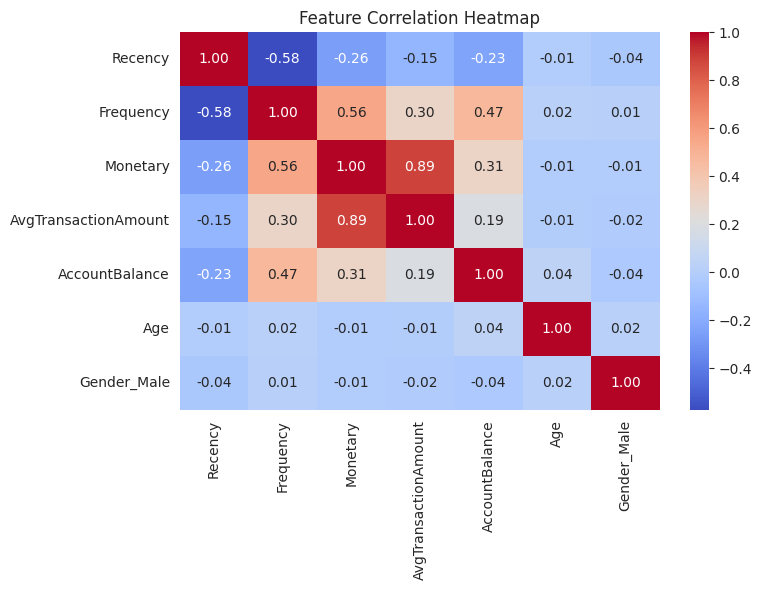

In [6]:
customer_df['Gender_Male'] = (customer_df['Gender'] == 'Male').astype(int)

feature_cols = ['Recency', 'Frequency', 'Monetary', 'AvgTransactionAmount',
                 'AccountBalance', 'Age', 'Gender_Male']

plt.figure(figsize=(8,6))
sns.heatmap(customer_df[feature_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('../reports/figures/correlation_heatmap.png', dpi=120)
plt.show()

## 5. Outlier check on engineered features

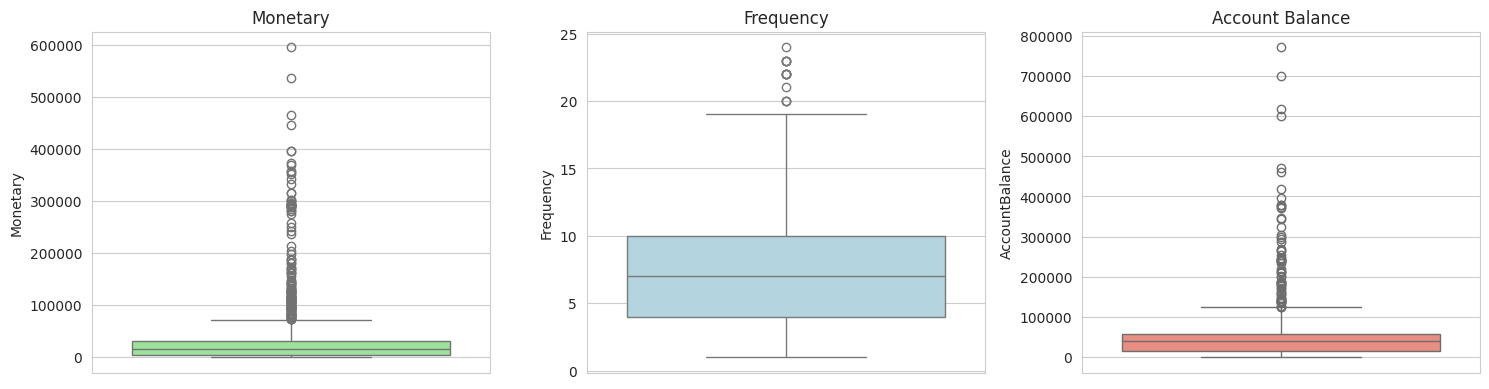

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.boxplot(y=customer_df['Monetary'], ax=axes[0], color='lightgreen')
axes[0].set_title('Monetary')
sns.boxplot(y=customer_df['Frequency'], ax=axes[1], color='lightblue')
axes[1].set_title('Frequency')
sns.boxplot(y=customer_df['AccountBalance'], ax=axes[2], color='salmon')
axes[2].set_title('Account Balance')
plt.tight_layout()
plt.savefig('../reports/figures/feature_boxplots.png', dpi=120)
plt.show()

## 6. Save the customer-level feature table

In [8]:
customer_df.to_csv('../data/processed/customer_features.csv', index=False)
customer_df.describe()

,Recency,Frequency,Monetary,AvgTransactionAmount,AccountBalance,Age,Gender_Male
count,778.000000,778.000000,778.000000,778.000000,778.000000,778.000000,778.000000
mean,75.809769,7.712082,42733.349602,4222.739279,56482.812815,41.191645,0.444730
std,86.229960,4.704321,77163.699787,7209.589709,77499.852634,12.748638,0.497256
min,1.000000,1.000000,71.080000,71.080000,296.870000,19.500000,0.000000
25%,14.000000,4.000000,4176.807500,985.492857,14826.737500,31.825000,0.000000
50%,38.000000,7.000000,14923.020000,2083.566917,39657.380000,40.700000,0.000000
75%,103.750000,10.000000,31573.855000,3503.730625,58836.417500,49.075000,1.000000
max,360.000000,24.000000,595733.330000,56299.322000,772078.460000,69.400000,1.000000
